<a href="https://colab.research.google.com/github/wisdomugwu654-cmyk/Automated-data-quality-/blob/main/Automated_Data_Quality_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

print("Automated Data Quality Dashboard")
print("Environment ready.")

Automated Data Quality Dashboard
Environment ready.


In [ ]:
import pandas as pd
import random
!pip install faker
from faker import Faker

fake = Faker()
random.seed(42)

records = []

for i in range(500):
    records.append({
        "customer_id": i + 1,
        "name": fake.name(),
        "email": fake.email(),
        "phone": fake.phone_number(),
        "date": fake.date_between(start_date="-2y", end_date="today"),
        "amount": round(random.uniform(1000, 500000), 2)
    })

df = pd.DataFrame(records)

# Convert dates to strings
df["date"] = df["date"].astype(str)

# -----------------------------
# INTENTIONALLY CREATE ERRORS
# -----------------------------

# 1. Missing values
for row in random.sample(range(500), 20):
    df.loc[row, "email"] = ""

for row in random.sample(range(500), 15):
    df.loc[row, "phone"] = ""

for row in random.sample(range(500), 10):
    df.loc[row, "amount"] = None

# 2. Invalid emails
invalid_emails = [
    "john@",
    "mary.gmail.com",
    "test@domain",
    "hello@.com",
    "invalid-email"
]

for row in random.sample(range(500), 15):
    df.loc[row, "email"] = random.choice(invalid_emails)

# 3. Extra spaces in names
for row in random.sample(range(500), 15):
    df.loc[row, "name"] = "  " + df.loc[row, "name"] + "  "

# 4. Uppercase names
for row in random.sample(range(500), 15):
    df.loc[row, "name"] = df.loc[row, "name"].upper()

# 5. Inconsistent phone formats
for row in random.sample(range(500), 20):
    df.loc[row, "phone"] = "080" + str(random.randint(10000000, 99999999))

# 6. Invalid transaction amounts
for row in random.sample(range(500), 5):
    df.loc[row, "amount"] = -random.randint(1000, 50000)

# 7. Duplicate records
duplicates = df.sample(47, random_state=42)
df = pd.concat([df, duplicates], ignore_index=True)

# Save the deliberately dirty dataset
df.to_csv("dirty_customer_data.csv", index=False)

print("Dataset created successfully.")
print("Total records:", len(df))
print("File saved as: dirty_customer_data.csv")

# Preview
display(df.head(10))

Dataset created successfully.
Total records: 547
File saved as: dirty_customer_data.csv


,customer_id,name,email,phone,date,amount
0,1,Lori Rodriguez,justinwebb@example.net,001-995-268-7672x0815,2026-05-01,320073.97
1,2,Laurie Rodriguez,jennifer03@example.org,651.374.9143x2312,2025-06-02,13480.37
2,3,Frank Adams,amandasantos@example.com,001-786-255-2653,2026-04-07,138239.63
3,4,Brandy Taylor,woodwardsharon@example.net,263-693-0161,2026-08-03,112382.16
4,5,Mary Cooley,bowmanrachel@example.net,6875341103,2024-12-04,368499.14
5,6,Dr. Zachary Vasquez,aabbott@example.com,001-545-617-6237x4365,2026-05-01,338673.04
6,7,Carlos Meza,ashley38@example.net,08074893936,2026-05-25,446197.60
7,8,Sue Chavez,barrcrystal@example.com,641-260-8707x0503,2026-01-20,44382.48
8,9,Whitney Flores,smithdaisy@example.net,534.785.0447x4205,2025-11-02,211538.99
9,10,Christine Knight,markgarcia@example.org,(798)899-8762x465,2025-11-20,NaN


In [ ]:

# Load the dirty dataset
df = pd.read_csv("dirty_customer_data.csv")

print("DATASET OVERVIEW")
print("=" * 40)

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumn names:")
print(list(df.columns))

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

DATASET OVERVIEW
Rows: 547
Columns: 6

Column names:
['customer_id', 'name', 'email', 'phone', 'date', 'amount']

Missing values:
customer_id     0
name            0
email          21
phone          16
date            0
amount         11
dtype: int64

Duplicate rows:
47

Data types:
customer_id      int64
name            object
email           object
phone           object
date            object
amount         float64
dtype: object


In [ ]:

# ==========================================
# DUPLICATE DETECTION
# ==========================================

# Identify duplicate rows
duplicate_mask = df.duplicated(keep="first")

# Create a table containing the duplicates
duplicate_records = df[duplicate_mask].copy()

# Add quality-control information
duplicate_records["error_type"] = "Duplicate record"
duplicate_records["confidence"] = 1.00
duplicate_records["action"] = "Remove duplicate"

print("DUPLICATE DETECTION REPORT")
print("=" * 40)

print("Total records:", len(df))
print("Duplicate records found:", duplicate_mask.sum())
print("Unique records:", (~duplicate_mask).sum())

print("\nConfidence score: 1.00")
print("Reason: Exact duplicate match")

print("\nSample duplicate records:")
display(duplicate_records.head(5))

DUPLICATE DETECTION REPORT
Total records: 547
Duplicate records found: 47
Unique records: 500

Confidence score: 1.00
Reason: Exact duplicate match

Sample duplicate records:


,customer_id,name,email,phone,date,amount,error_type,confidence,action
500,362,Renee Miller,darrell53@example.org,417-764-9034,2025-07-18,157524.98,Duplicate record,1.0,Remove duplicate
501,74,Justin Moreno,qbrown@example.net,222.770.9928x3699,2026-06-13,158024.26,Duplicate record,1.0,Remove duplicate
502,375,Kathleen Kennedy,hcobb@example.org,(536)736-8359x332,2024-08-28,182746.51,Duplicate record,1.0,Remove duplicate
503,156,Christopher Lee,chloehale@example.net,519.898.4454x789,2026-08-03,113123.97,Duplicate record,1.0,Remove duplicate
504,105,Tyler Perez,ortizkevin@example.com,633-618-8126x017,2026-04-04,134145.77,Duplicate record,1.0,Remove duplicate


In [ ]:

# ==========================================
# EMAIL VALIDATION
# ==========================================

import re

def validate_email(email):
    """
    Returns True if the email has a basic valid structure.
    """
    if pd.isna(email) or str(email).strip() == "":
        return False

    pattern = r"^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$"

    return bool(re.match(pattern, str(email).strip()))


# Check every email
df["email_valid"] = df["email"].apply(validate_email)

# Find invalid emails
invalid_email_mask = ~df["email_valid"]

invalid_emails = df[invalid_email_mask].copy()

# Add quality-control information
invalid_emails["error_type"] = "Invalid email"
invalid_emails["confidence"] = 0.98
invalid_emails["action"] = "Review / correct email"

print("EMAIL VALIDATION REPORT")
print("=" * 40)

print("Total records checked:", len(df))
print("Valid emails:", df["email_valid"].sum())
print("Invalid emails:", invalid_email_mask.sum())

print("\nConfidence score: 0.98")
print("Reason: Email does not match expected format")

print("\nSample invalid emails:")
display(
    invalid_emails[
        ["customer_id", "name", "email", "confidence", "action"]
    ].head(10)
)

EMAIL VALIDATION REPORT
Total records checked: 547
Valid emails: 509
Invalid emails: 38

Confidence score: 0.98
Reason: Email does not match expected format

Sample invalid emails:


,customer_id,name,email,confidence,action
10,11,Richard Brandt,john@,0.98,Review / correct email
13,14,Charles Ramos,NaN,0.98,Review / correct email
15,16,Jose Kelley,test@domain,0.98,Review / correct email
20,21,David Brown,mary.gmail.com,0.98,Review / correct email
25,26,Hannah Montoya,NaN,0.98,Review / correct email
42,43,Jeremy Romero,NaN,0.98,Review / correct email
64,65,Alicia Murphy,invalid-email,0.98,Review / correct email
69,70,Mrs. Katrina King,NaN,0.98,Review / correct email
78,79,Mrs. Lisa Odom,test@domain,0.98,Review / correct email
93,94,Sean Valencia,NaN,0.98,Review / correct email


In [ ]:

# ==========================================
# MISSING VALUE DETECTION
# ==========================================

missing_report = []

for column in df.columns:
    # Skip our temporary email validation column
    if column == "email_valid":
        continue

    missing_mask = df[column].isna() | (df[column].astype(str).str.strip() == "")
    missing_count = missing_mask.sum()

    if missing_count > 0:
        missing_report.append({
            "field": column,
            "missing_records": int(missing_count),
            "confidence": 1.00,
            "action": "Review / fill missing value"
        })

missing_df = pd.DataFrame(missing_report)

print("MISSING VALUE REPORT")
print("=" * 40)

if len(missing_df) > 0:
    display(missing_df)

    print("\nTotal missing values:",
          missing_df["missing_records"].sum())
else:
    print("No missing values detected.")

MISSING VALUE REPORT


,field,missing_records,confidence,action
0,email,21,1.0,Review / fill missing value
1,phone,16,1.0,Review / fill missing value
2,amount,11,1.0,Review / fill missing value



Total missing values: 48


In [ ]:

# ==========================================
# NAME FORMAT CONSISTENCY CHECK
# ==========================================

def check_name_format(name):
    if pd.isna(name):
        return "Missing"

    name = str(name)

    if name != name.strip():
        return "Extra whitespace"

    if name.isupper():
        return "Uppercase"

    return "Consistent"


# Check every name
df["name_format"] = df["name"].apply(check_name_format)

# Find inconsistent names
inconsistent_names = df[df["name_format"] != "Consistent"].copy()

# Add quality-control information
inconsistent_names["error_type"] = "Name format inconsistency"
inconsistent_names["confidence"] = 0.99
inconsistent_names["action"] = "Standardize name"

print("NAME FORMAT REPORT")
print("=" * 40)

print("Total names checked:", len(df))
print("Inconsistent names:", len(inconsistent_names))

print("\nConfidence score: 0.99")
print("Reason: Detectable formatting inconsistency")

print("\nBreakdown:")
print(df["name_format"].value_counts())

print("\nSample inconsistent names:")
display(
    inconsistent_names[
        ["customer_id", "name", "name_format", "confidence", "action"]
    ].head(10)
)

NAME FORMAT REPORT
Total names checked: 547
Inconsistent names: 35

Confidence score: 0.99
Reason: Detectable formatting inconsistency

Breakdown:
name_format
Consistent          512
Extra whitespace     18
Uppercase            17
Name: count, dtype: int64

Sample inconsistent names:


,customer_id,name,name_format,confidence,action
21,22,SHAWN THOMPSON,Uppercase,0.99,Standardize name
38,39,Emily Adams,Extra whitespace,0.99,Standardize name
52,53,LISA LEWIS,Uppercase,0.99,Standardize name
61,62,EDGAR SCHWARTZ,Uppercase,0.99,Standardize name
101,102,Ryan Kaufman,Extra whitespace,0.99,Standardize name
124,125,NANCY CRANE,Uppercase,0.99,Standardize name
154,155,GREGORY WILLIAMSON,Uppercase,0.99,Standardize name
159,160,Hannah Williams,Extra whitespace,0.99,Standardize name
192,193,Kelly Moore,Extra whitespace,0.99,Standardize name
203,204,Michael Roy,Extra whitespace,0.99,Standardize name


In [ ]:

# ==========================================
# TRANSACTION AMOUNT VALIDATION
# ==========================================

# Convert amount to numeric in case values were stored as text
df["amount_numeric"] = pd.to_numeric(df["amount"], errors="coerce")

# Identify negative amounts
negative_amount_mask = df["amount_numeric"] < 0

negative_amounts = df[negative_amount_mask].copy()

# Add quality-control information
negative_amounts["error_type"] = "Invalid negative amount"
negative_amounts["confidence"] = 1.00
negative_amounts["action"] = "Review / correct amount"

print("TRANSACTION AMOUNT REPORT")
print("=" * 40)

print("Total records checked:", len(df))
print("Negative amounts:", negative_amount_mask.sum())

print("\nConfidence score: 1.00")
print("Reason: Transaction amount cannot be negative")

print("\nSample invalid amounts:")

display(
    negative_amounts[
        ["customer_id", "name", "amount", "confidence", "action"]
    ].head(10)
)

TRANSACTION AMOUNT REPORT
Total records checked: 547
Negative amounts: 6

Confidence score: 1.00
Reason: Transaction amount cannot be negative

Sample invalid amounts:


,customer_id,name,amount,confidence,action
237,238,Mark Steele,-23046.0,1.0,Review / correct amount
291,292,Anna Johnson,-2880.0,1.0,Review / correct amount
312,313,Tammy Butler,-33394.0,1.0,Review / correct amount
342,343,Nicole Banks,-22300.0,1.0,Review / correct amount
384,385,Tammy Carter,-25837.0,1.0,Review / correct amount
540,385,Tammy Carter,-25837.0,1.0,Review / correct amount


In [ ]:

# ==========================================
# UNIFIED ERROR REPORT
# ==========================================

error_reports = []

# ------------------------------------------
# 1. DUPLICATES
# ------------------------------------------

for index in df[duplicate_mask].index:
    error_reports.append({
        "record_index": index,
        "customer_id": df.loc[index, "customer_id"],
        "field": "record",
        "error_type": "Duplicate record",
        "old_value": "Duplicate",
        "new_value": "",
        "confidence": 1.00,
        "action": "Remove duplicate"
    })


# ------------------------------------------
# 2. INVALID EMAILS
# ------------------------------------------

for index in df[invalid_email_mask].index:
    email = df.loc[index, "email"]

    error_reports.append({
        "record_index": index,
        "customer_id": df.loc[index, "customer_id"],
        "field": "email",
        "error_type": "Invalid email",
        "old_value": str(email),
        "new_value": "",
        "confidence": 0.98,
        "action": "Review / correct email"
    })


# ------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------

for column in ["email", "phone", "amount"]:
    missing_mask = (
        df[column].isna() |
        (df[column].astype(str).str.strip() == "")
    )

    for index in df[missing_mask].index:
        error_reports.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": column,
            "error_type": "Missing value",
            "old_value": "",
            "new_value": "",
            "confidence": 1.00,
            "action": "Review / fill missing value"
        })


# ------------------------------------------
# 4. NAME FORMAT ISSUES
# ------------------------------------------

for index in inconsistent_names.index:
    name = df.loc[index, "name"]

    error_reports.append({
        "record_index": index,
        "customer_id": df.loc[index, "customer_id"],
        "field": "name",
        "error_type": "Name format inconsistency",
        "old_value": str(name),
        "new_value": str(name).strip().title(),
        "confidence": 0.99,
        "action": "Standardize name"
    })


# ------------------------------------------
# 5. NEGATIVE AMOUNTS
# ------------------------------------------

for index in negative_amounts.index:
    amount = df.loc[index, "amount"]

    error_reports.append({
        "record_index": index,
        "customer_id": df.loc[index, "customer_id"],
        "field": "amount",
        "error_type": "Invalid negative amount",
        "old_value": str(amount),
        "new_value": "",
        "confidence": 1.00,
        "action": "Review / correct amount"
    })


# ------------------------------------------
# CREATE ERROR REPORT
# ------------------------------------------

error_report = pd.DataFrame(error_reports)

print("UNIFIED DATA QUALITY REPORT")
print("=" * 50)

print("Total issues detected:", len(error_report))

print("\nIssues by type:")
print(error_report["error_type"].value_counts())

print("\nConfidence summary:")
print(error_report["confidence"].describe())

print("\nSample error records:")
display(error_report.head(10))

UNIFIED DATA QUALITY REPORT
Total issues detected: 174

Issues by type:
error_type
Missing value                48
Duplicate record             47
Invalid email                38
Name format inconsistency    35
Invalid negative amount       6
Name: count, dtype: int64

Confidence summary:
count    174.000000
mean       0.993621
std        0.008195
min        0.980000
25%        0.990000
50%        1.000000
75%        1.000000
max        1.000000
Name: confidence, dtype: float64

Sample error records:


,record_index,customer_id,field,error_type,old_value,new_value,confidence,action
0,500,362,record,Duplicate record,Duplicate,,1.0,Remove duplicate
1,501,74,record,Duplicate record,Duplicate,,1.0,Remove duplicate
2,502,375,record,Duplicate record,Duplicate,,1.0,Remove duplicate
3,503,156,record,Duplicate record,Duplicate,,1.0,Remove duplicate
4,504,105,record,Duplicate record,Duplicate,,1.0,Remove duplicate
5,505,395,record,Duplicate record,Duplicate,,1.0,Remove duplicate
6,506,378,record,Duplicate record,Duplicate,,1.0,Remove duplicate
7,507,125,record,Duplicate record,Duplicate,,1.0,Remove duplicate
8,508,69,record,Duplicate record,Duplicate,,1.0,Remove duplicate
9,509,451,record,Duplicate record,Duplicate,,1.0,Remove duplicate


In [ ]:

# ==========================================
# AUTOMATED CLEANING ENGINE
# ==========================================

# Start with a copy of the original dataset
cleaned_df = df.copy()

# ------------------------------------------
# 1. REMOVE EXACT DUPLICATES
# ------------------------------------------

records_before = len(cleaned_df)

cleaned_df = cleaned_df.drop_duplicates(
    keep="first"
).copy()

duplicates_removed = records_before - len(cleaned_df)


# ------------------------------------------
# 2. STANDARDIZE NAMES
# ------------------------------------------

cleaned_df["name"] = (
    cleaned_df["name"]
    .astype(str)
    .str.strip()
    .str.title()
)


# ------------------------------------------
# 3. STANDARDIZE PHONE NUMBERS
# ------------------------------------------

def clean_phone(phone):
    if pd.isna(phone):
        return ""

    phone = str(phone).strip()

    # Keep only numbers
    digits = re.sub(r"\D", "", phone)

    # Convert Nigerian 080... format to 23480...
    if digits.startswith("0") and len(digits) == 11:
        digits = "234" + digits[1:]

    return digits


cleaned_df["phone"] = cleaned_df["phone"].apply(clean_phone)


# ------------------------------------------
# 4. STANDARDIZE EMAILS
# ------------------------------------------

cleaned_df["email"] = (
    cleaned_df["email"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)


# ------------------------------------------
# 5. STANDARDIZE AMOUNTS
# ------------------------------------------

cleaned_df["amount"] = pd.to_numeric(
    cleaned_df["amount"],
    errors="coerce"
)


# ------------------------------------------
# 6. REMOVE TEMPORARY QUALITY-CHECK COLUMNS
# ------------------------------------------

temporary_columns = [
    "email_valid",
    "name_format",
    "amount_numeric"
]

cleaned_df = cleaned_df.drop(
    columns=[
        column for column in temporary_columns
        if column in cleaned_df.columns
    ]
)


# ------------------------------------------
# 7. SAVE CLEANED DATASET
# ------------------------------------------

cleaned_df.to_csv(
    "cleaned_customer_data.csv",
    index=False
)


# ------------------------------------------
# CLEANING SUMMARY
# ------------------------------------------

print("AUTOMATED CLEANING COMPLETE")
print("=" * 50)

print("Original records:", records_before)
print("Clean records:", len(cleaned_df))
print("Duplicates removed:", duplicates_removed)

print("\nCleaned columns:")
print(list(cleaned_df.columns))

print("\nCleaned dataset preview:")
display(cleaned_df.head(10))

AUTOMATED CLEANING COMPLETE
Original records: 547
Clean records: 500
Duplicates removed: 47

Cleaned columns:
['customer_id', 'name', 'email', 'phone', 'date', 'amount']

Cleaned dataset preview:


,customer_id,name,email,phone,date,amount
0,1,Lori Rodriguez,justinwebb@example.net,00199526876720815,2026-05-01,320073.97
1,2,Laurie Rodriguez,jennifer03@example.org,65137491432312,2025-06-02,13480.37
2,3,Frank Adams,amandasantos@example.com,0017862552653,2026-04-07,138239.63
3,4,Brandy Taylor,woodwardsharon@example.net,2636930161,2026-08-03,112382.16
4,5,Mary Cooley,bowmanrachel@example.net,6875341103,2024-12-04,368499.14
5,6,Dr. Zachary Vasquez,aabbott@example.com,00154561762374365,2026-05-01,338673.04
6,7,Carlos Meza,ashley38@example.net,2348074893936,2026-05-25,446197.60
7,8,Sue Chavez,barrcrystal@example.com,64126087070503,2026-01-20,44382.48
8,9,Whitney Flores,smithdaisy@example.net,53478504474205,2025-11-02,211538.99
9,10,Christine Knight,markgarcia@example.org,7988998762465,2025-11-20,NaN


In [ ]:

# ==========================================
# AUDIT TRAIL
# ==========================================

audit_log = []

# ------------------------------------------
# 1. DUPLICATES REMOVED
# ------------------------------------------

for index in duplicate_records.index:
    audit_log.append({
        "record_index": index,
        "customer_id": df.loc[index, "customer_id"],
        "field": "record",
        "old_value": "Duplicate record",
        "new_value": "",
        "action": "Removed",
        "reason": "Exact duplicate",
        "confidence": 1.00
    })


# ------------------------------------------
# 2. NAME STANDARDIZATION
# ------------------------------------------

for index in df.index:

    original = str(df.loc[index, "name"])

    if pd.isna(df.loc[index, "name"]):
        continue

    cleaned = original.strip().title()

    if original != cleaned:
        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "name",
            "old_value": original,
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Name format inconsistency",
            "confidence": 0.99
        })


# ------------------------------------------
# 3. PHONE STANDARDIZATION
# ------------------------------------------

for index in df.index:

    original = df.loc[index, "phone"]

    if pd.isna(original) or str(original).strip() == "":
        continue

    cleaned = clean_phone(original)

    if str(original).strip() != cleaned:
        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "phone",
            "old_value": str(original),
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Phone format inconsistency",
            "confidence": 0.95
        })


# ------------------------------------------
# 4. EMAIL STANDARDIZATION
# ------------------------------------------

for index in df.index:

    original = df.loc[index, "email"]

    if pd.isna(original):
        continue

    cleaned = str(original).strip().lower()

    if str(original) != cleaned:
        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "email",
            "old_value": str(original),
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Email formatting",
            "confidence": 0.99
        })


# ------------------------------------------
# CREATE AUDIT LOG
# ------------------------------------------

audit_df = pd.DataFrame(audit_log)

audit_df.to_csv(
    "audit_log.csv",
    index=False
)


# ------------------------------------------
# SUMMARY
# ------------------------------------------

print("AUDIT TRAIL CREATED")
print("=" * 50)

print("Total audit events:", len(audit_df))

print("\nActions:")
print(audit_df["action"].value_counts())

print("\nAudit log preview:")
display(audit_df.head(10))

AUDIT TRAIL CREATED
Total audit events: 589

Actions:
action
Standardized    542
Removed          47
Name: count, dtype: int64

Audit log preview:


,record_index,customer_id,field,old_value,new_value,action,reason,confidence
0,500,362,record,Duplicate record,,Removed,Exact duplicate,1.0
1,501,74,record,Duplicate record,,Removed,Exact duplicate,1.0
2,502,375,record,Duplicate record,,Removed,Exact duplicate,1.0
3,503,156,record,Duplicate record,,Removed,Exact duplicate,1.0
4,504,105,record,Duplicate record,,Removed,Exact duplicate,1.0
5,505,395,record,Duplicate record,,Removed,Exact duplicate,1.0
6,506,378,record,Duplicate record,,Removed,Exact duplicate,1.0
7,507,125,record,Duplicate record,,Removed,Exact duplicate,1.0
8,508,69,record,Duplicate record,,Removed,Exact duplicate,1.0
9,509,451,record,Duplicate record,,Removed,Exact duplicate,1.0


In [ ]:

# ==========================================
# IMPROVED AUDIT TRAIL
# ==========================================

audit_log = []

# ------------------------------------------
# 1. DUPLICATES REMOVED
# ------------------------------------------

for index in duplicate_records.index:

    audit_log.append({
        "record_index": index,
        "customer_id": df.loc[index, "customer_id"],
        "field": "record",
        "old_value": "Duplicate record",
        "new_value": "",
        "action": "Removed",
        "reason": "Exact duplicate",
        "confidence": 1.00
    })


# ------------------------------------------
# 2. NAME STANDARDIZATION
# ------------------------------------------

for index in df.index:

    original = df.loc[index, "name"]

    if pd.isna(original):
        continue

    original = str(original)
    cleaned = original.strip().title()

    # Only log genuine formatting changes
    if original != cleaned:

        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "name",
            "old_value": original,
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Name format inconsistency",
            "confidence": 0.99
        })


# ------------------------------------------
# 3. PHONE STANDARDIZATION
# ------------------------------------------

for index in df.index:

    original = df.loc[index, "phone"]

    if pd.isna(original) or str(original).strip() == "":
        continue

    original = str(original).strip()
    cleaned = clean_phone(original)

    # Only log if formatting actually changed
    if original != cleaned:

        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "phone",
            "old_value": original,
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Phone format inconsistency",
            "confidence": 0.95
        })


# ------------------------------------------
# 4. EMAIL STANDARDIZATION
# ------------------------------------------

for index in df.index:

    original = df.loc[index, "email"]

    if pd.isna(original) or str(original).strip() == "":
        continue

    original = str(original)
    cleaned = original.strip().lower()

    # Only log actual formatting changes
    if original != cleaned:

        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "email",
            "old_value": original,
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Email formatting",
            "confidence": 0.99
        })


# ------------------------------------------
# CREATE IMPROVED AUDIT LOG
# ------------------------------------------

audit_df = pd.DataFrame(audit_log)

audit_df.to_csv(
    "audit_log.csv",
    index=False
)


# ------------------------------------------
# SUMMARY
# ------------------------------------------

print("IMPROVED AUDIT TRAIL")
print("=" * 50)

print("Total audit events:", len(audit_df))

print("\nActions:")
print(audit_df["action"].value_counts())

print("\nAudit log preview:")
display(audit_df.head(10))

IMPROVED AUDIT TRAIL
Total audit events: 589

Actions:
action
Standardized    542
Removed          47
Name: count, dtype: int64

Audit log preview:


,record_index,customer_id,field,old_value,new_value,action,reason,confidence
0,500,362,record,Duplicate record,,Removed,Exact duplicate,1.0
1,501,74,record,Duplicate record,,Removed,Exact duplicate,1.0
2,502,375,record,Duplicate record,,Removed,Exact duplicate,1.0
3,503,156,record,Duplicate record,,Removed,Exact duplicate,1.0
4,504,105,record,Duplicate record,,Removed,Exact duplicate,1.0
5,505,395,record,Duplicate record,,Removed,Exact duplicate,1.0
6,506,378,record,Duplicate record,,Removed,Exact duplicate,1.0
7,507,125,record,Duplicate record,,Removed,Exact duplicate,1.0
8,508,69,record,Duplicate record,,Removed,Exact duplicate,1.0
9,509,451,record,Duplicate record,,Removed,Exact duplicate,1.0


In [ ]:

# ==========================================
# FINAL PHONE CLEANING + AUDIT FIX
# ==========================================

def clean_phone_safe(phone):
    """
    Only automatically converts a clear Nigerian
    local 11-digit format: 08012345678
    into: 2348012345678

    Other formats are left unchanged.
    """

    if pd.isna(phone) or str(phone).strip() == "":
        return phone

    original = str(phone).strip()

    # Only change a clear 11-digit Nigerian local number
    if re.fullmatch(r"0\d{10}", original):
        return "234" + original[1:]

    return original


# ------------------------------------------
# REBUILD CLEANED DATASET
# ------------------------------------------

cleaned_df = df.copy()

# Remove exact duplicates
cleaned_df = cleaned_df.drop_duplicates(
    keep="first"
).copy()

# Standardize names
cleaned_df["name"] = (
    cleaned_df["name"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.title()
)

# Safely standardize phones
cleaned_df["phone"] = cleaned_df["phone"].apply(
    clean_phone_safe
)

# Standardize emails
cleaned_df["email"] = (
    cleaned_df["email"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

# Convert amount to numeric
cleaned_df["amount"] = pd.to_numeric(
    cleaned_df["amount"],
    errors="coerce"
)

# Remove temporary columns
temporary_columns = [
    "email_valid",
    "name_format",
    "amount_numeric"
]

cleaned_df = cleaned_df.drop(
    columns=[
        col for col in temporary_columns
        if col in cleaned_df.columns
    ]
)

# Save
cleaned_df.to_csv(
    "cleaned_customer_data.csv",
    index=False
)


# ==========================================
# REBUILD AUDIT LOG
# ==========================================

audit_log = []

# 1. DUPLICATES
for index in duplicate_records.index:

    audit_log.append({
        "record_index": index,
        "customer_id": df.loc[index, "customer_id"],
        "field": "record",
        "old_value": "Duplicate record",
        "new_value": "",
        "action": "Removed",
        "reason": "Exact duplicate",
        "confidence": 1.00
    })


# 2. NAME CHANGES
for index in df.index:

    original = df.loc[index, "name"]

    if pd.isna(original):
        continue

    original = str(original)
    cleaned = original.strip().title()

    if original != cleaned:

        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "name",
            "old_value": original,
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Name format inconsistency",
            "confidence": 0.99
        })


# 3. PHONE CHANGES
for index in df.index:

    original = df.loc[index, "phone"]

    if pd.isna(original) or str(original).strip() == "":
        continue

    original = str(original).strip()
    cleaned = clean_phone_safe(original)

    if original != cleaned:

        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "phone",
            "old_value": original,
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Nigerian local phone format",
            "confidence": 0.99
        })


# 4. EMAIL FORMAT CHANGES
for index in df.index:

    original = df.loc[index, "email"]

    if pd.isna(original) or str(original).strip() == "":
        continue

    original = str(original)
    cleaned = original.strip().lower()

    if original != cleaned:

        audit_log.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "email",
            "old_value": original,
            "new_value": cleaned,
            "action": "Standardized",
            "reason": "Email formatting",
            "confidence": 0.99
        })


# Create audit dataframe
audit_df = pd.DataFrame(audit_log)

audit_df.to_csv(
    "audit_log.csv",
    index=False
)


# ==========================================
# FINAL AUDIT SUMMARY
# ==========================================

print("FINAL AUDIT TRAIL")
print("=" * 50)

print("Total audit events:", len(audit_df))

print("\nActions:")
print(audit_df["action"].value_counts())

print("\nCleaned records:", len(cleaned_df))
print("Duplicates removed:", len(df) - len(cleaned_df))

print("\nAudit preview:")
display(audit_df.head(10))

FINAL AUDIT TRAIL
Total audit events: 110

Actions:
action
Standardized    63
Removed         47
Name: count, dtype: int64

Cleaned records: 500
Duplicates removed: 47

Audit preview:


,record_index,customer_id,field,old_value,new_value,action,reason,confidence
0,500,362,record,Duplicate record,,Removed,Exact duplicate,1.0
1,501,74,record,Duplicate record,,Removed,Exact duplicate,1.0
2,502,375,record,Duplicate record,,Removed,Exact duplicate,1.0
3,503,156,record,Duplicate record,,Removed,Exact duplicate,1.0
4,504,105,record,Duplicate record,,Removed,Exact duplicate,1.0
5,505,395,record,Duplicate record,,Removed,Exact duplicate,1.0
6,506,378,record,Duplicate record,,Removed,Exact duplicate,1.0
7,507,125,record,Duplicate record,,Removed,Exact duplicate,1.0
8,508,69,record,Duplicate record,,Removed,Exact duplicate,1.0
9,509,451,record,Duplicate record,,Removed,Exact duplicate,1.0


In [ ]:

# ==========================================
# FINAL DATA QUALITY SCORE
# ==========================================

# Re-check the cleaned dataset
remaining_issues = 0

# 1. Missing values
missing_after_cleaning = (
    cleaned_df.isna().sum().sum()
)

# Also count blank strings
blank_after_cleaning = 0

for column in cleaned_df.columns:
    blank_after_cleaning += (
        cleaned_df[column]
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

# 2. Invalid emails
invalid_email_after_cleaning = (
    ~cleaned_df["email"].apply(validate_email)
).sum()

# 3. Negative amounts
negative_amount_after_cleaning = (
    cleaned_df["amount"] < 0
).sum()

# Total remaining issues
remaining_issues = (
    missing_after_cleaning
    + invalid_email_after_cleaning
    + negative_amount_after_cleaning
)

# Calculate a simple quality score
total_possible_checks = len(cleaned_df) * 3

quality_score = (
    1 - (remaining_issues / total_possible_checks)
) * 100

# Prevent score from going outside 0-100
quality_score = max(0, min(100, quality_score))


# ==========================================
# FINAL REPORT
# ==========================================

print("FINAL DATA QUALITY SCORE")
print("=" * 50)

print(f"Original records:          {len(df)}")
print(f"Clean records:             {len(cleaned_df)}")
print(f"Duplicates removed:        {len(df) - len(cleaned_df)}")
print(f"Audit events:              {len(audit_df)}")

print("\nRemaining issues:")
print(f"Missing values:             {missing_after_cleaning}")
print(f"Invalid emails:             {invalid_email_after_cleaning}")
print(f"Negative amounts:           {negative_amount_after_cleaning}")

print("\n----------------------------------------")
print(f"FINAL DATA QUALITY SCORE: {quality_score:.1f}%")
print("----------------------------------------")

FINAL DATA QUALITY SCORE
Original records:          547
Clean records:             500
Duplicates removed:        47
Audit events:              110

Remaining issues:
Missing values:             24
Invalid emails:             34
Negative amounts:           5

----------------------------------------
FINAL DATA QUALITY SCORE: 95.8%
----------------------------------------


        AUTOMATED DATA QUALITY DASHBOARD

PROCESSING SUMMARY
------------------------------------------------------------
Records processed:        547
Clean records retained:   500
Duplicates removed:       47
Audit events recorded:    110

REMAINING ISSUES
------------------------------------------------------------
Missing values:            24
Invalid emails:            34
Negative amounts:          5

QUALITY SCORE
------------------------------------------------------------
Final data quality score:  95.8%



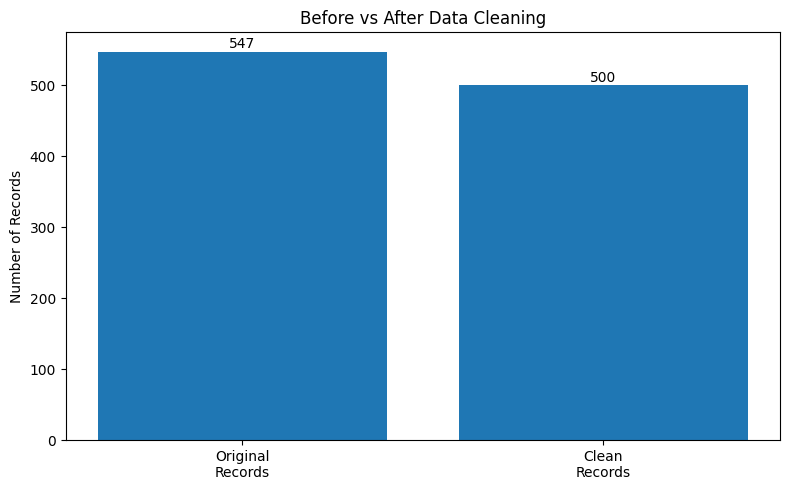

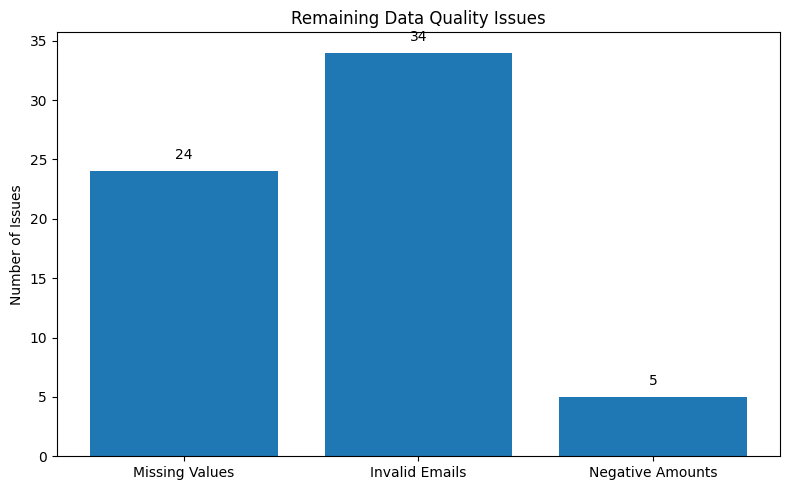

In [ ]:

# ==========================================
# BEFORE vs AFTER DASHBOARD
# ==========================================

import matplotlib.pyplot as plt

# Metrics
before_records = len(df)
after_records = len(cleaned_df)

duplicates_removed = len(df) - len(cleaned_df)

audit_events = len(audit_df)

missing_values = missing_after_cleaning
invalid_emails = invalid_email_after_cleaning
negative_amounts = negative_amount_after_cleaning

quality_score = quality_score


# ==========================================
# PRINT DASHBOARD SUMMARY
# ==========================================

print("=" * 60)
print("        AUTOMATED DATA QUALITY DASHBOARD")
print("=" * 60)

print()
print("PROCESSING SUMMARY")
print("-" * 60)

print(f"Records processed:        {before_records}")
print(f"Clean records retained:   {after_records}")
print(f"Duplicates removed:       {duplicates_removed}")
print(f"Audit events recorded:    {audit_events}")

print()
print("REMAINING ISSUES")
print("-" * 60)

print(f"Missing values:            {missing_values}")
print(f"Invalid emails:            {invalid_emails}")
print(f"Negative amounts:          {negative_amounts}")

print()
print("QUALITY SCORE")
print("-" * 60)

print(f"Final data quality score:  {quality_score:.1f}%")

print()
print("=" * 60)


# ==========================================
# BEFORE vs AFTER CHART
# ==========================================

labels = [
    "Original\nRecords",
    "Clean\nRecords"
]

values = [
    before_records,
    after_records
]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.title("Before vs After Data Cleaning")
plt.ylabel("Number of Records")

for i, value in enumerate(values):
    plt.text(
        i,
        value + 5,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()


# ==========================================
# REMAINING ISSUES CHART
# ==========================================

issue_labels = [
    "Missing Values",
    "Invalid Emails",
    "Negative Amounts"
]

issue_values = [
    missing_values,
    invalid_emails,
    negative_amounts
]

plt.figure(figsize=(8, 5))

plt.bar(issue_labels, issue_values)

plt.title("Remaining Data Quality Issues")
plt.ylabel("Number of Issues")

for i, value in enumerate(issue_values):
    plt.text(
        i,
        value + 1,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:

# ==========================================
# PROCESSING TIME
# ==========================================

import time

start_time = time.perf_counter()

# Run the cleaning process again
test_df = df.copy()

test_df = test_df.drop_duplicates(keep="first").copy()

test_df["name"] = (
    test_df["name"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.title()
)

test_df["phone"] = test_df["phone"].apply(
    clean_phone_safe
)

test_df["email"] = (
    test_df["email"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

test_df["amount"] = pd.to_numeric(
    test_df["amount"],
    errors="coerce"
)

processing_time = time.perf_counter() - start_time


# ==========================================
# PERFORMANCE RESULT
# ==========================================

print("PERFORMANCE METRIC")
print("=" * 40)

print(f"Records processed: {len(df)}")
print(f"Records retained: {len(test_df)}")
print(f"Processing time: {processing_time:.4f} seconds")

if processing_time > 0:
    print(
        f"Processing speed: "
        f"{len(df) / processing_time:.0f} records/second"
    )

PERFORMANCE METRIC
Records processed: 547
Records retained: 500
Processing time: 0.0111 seconds
Processing speed: 49287 records/second


In [ ]:

# ==========================================
# ROBUST CONFIDENCE SCORE ANALYSIS
# ==========================================

import pandas as pd
import re

# ------------------------------------------
# 1. CHECK THAT THE ORIGINAL DATA EXISTS
# ------------------------------------------

if "df" not in globals():
    raise NameError(
        "The original dataset 'df' is not available. "
        "Please run the dataset loading cell first."
    )


# ------------------------------------------
# 2. EMAIL VALIDATOR
# ------------------------------------------

def validate_email_safe(email):

    if pd.isna(email):
        return False

    email = str(email).strip()

    if email == "":
        return False

    pattern = r"^[^@\s]+@[^@\s]+\.[^@\s]+$"

    return bool(re.match(pattern, email))


# ------------------------------------------
# 3. CREATE ERROR REPORT
#    IF IT DOES NOT ALREADY EXIST
# ------------------------------------------

if "error_report" not in globals():

    error_records = []

    # --------------------------------------
    # MISSING VALUES
    # --------------------------------------

    for index, row in df.iterrows():

        for column in df.columns:

            if pd.isna(row[column]) or str(row[column]).strip() == "":

                error_records.append({
                    "record_index": index,
                    "customer_id": row["customer_id"],
                    "field": column,
                    "error_type": "Missing value",
                    "old_value": "",
                    "confidence": 1.00
                })


    # --------------------------------------
    # INVALID EMAILS
    # --------------------------------------

    if "email" in df.columns:

        for index, row in df.iterrows():

            email = row["email"]

            if not pd.isna(email) and str(email).strip() != "":

                if not validate_email_safe(email):

                    error_records.append({
                        "record_index": index,
                        "customer_id": row["customer_id"],
                        "field": "email",
                        "error_type": "Invalid email",
                        "old_value": str(email),
                        "confidence": 0.98
                    })


    # --------------------------------------
    # NEGATIVE AMOUNTS
    # --------------------------------------

    if "amount" in df.columns:

        numeric_amount = pd.to_numeric(
            df["amount"],
            errors="coerce"
        )

        for index in df.index:

            amount = numeric_amount.loc[index]

            if pd.notna(amount) and amount < 0:

                error_records.append({
                    "record_index": index,
                    "customer_id": df.loc[index, "customer_id"],
                    "field": "amount",
                    "error_type": "Invalid negative amount",
                    "old_value": str(df.loc[index, "amount"]),
                    "confidence": 0.99
                })


    # --------------------------------------
    # DUPLICATES
    # --------------------------------------

    duplicate_mask = df.duplicated(
        keep="first"
    )

    for index in df.index[duplicate_mask]:

        error_records.append({
            "record_index": index,
            "customer_id": df.loc[index, "customer_id"],
            "field": "record",
            "error_type": "Duplicate record",
            "old_value": "Duplicate",
            "confidence": 1.00
        })


    # --------------------------------------
    # CREATE DATAFRAME
    # --------------------------------------

    error_report = pd.DataFrame(error_records)


# ------------------------------------------
# 4. CHECK CONFIDENCE COLUMN
# ------------------------------------------

if "confidence" not in error_report.columns:

    raise ValueError(
        "The error report exists, but it has no "
        "'confidence' column."
    )


# ------------------------------------------
# 5. ENSURE CONFIDENCE IS NUMERIC
# ------------------------------------------

error_report["confidence"] = pd.to_numeric(
    error_report["confidence"],
    errors="coerce"
)


# Remove rows where confidence couldn't be calculated
error_report = error_report.dropna(
    subset=["confidence"]
).copy()


# ------------------------------------------
# 6. CONFIDENCE CATEGORIES
# ------------------------------------------

error_report["confidence_level"] = pd.cut(
    error_report["confidence"],
    bins=[-0.01, 0.70, 0.90, 1.00],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)


# ------------------------------------------
# 7. CALCULATE METRICS
# ------------------------------------------

total_issues = len(error_report)

average_confidence = (
    error_report["confidence"].mean()
    if total_issues > 0
    else 0
)

high_confidence = (
    error_report["confidence"] >= 0.90
).sum()

medium_confidence = (
    (error_report["confidence"] >= 0.70) &
    (error_report["confidence"] < 0.90)
).sum()

low_confidence = (
    error_report["confidence"] < 0.70
).sum()


# ------------------------------------------
# 8. DISPLAY RESULTS
# ------------------------------------------

print("=" * 55)
print("        CONFIDENCE SCORE ANALYSIS")
print("=" * 55)

print()
print(f"Total flagged issues:       {total_issues}")
print(f"Average confidence:         {average_confidence:.1%}")

print()
print("CONFIDENCE DISTRIBUTION")
print("-" * 55)

print(f"High confidence (90%+):     {high_confidence}")
print(f"Medium confidence (70-89%): {medium_confidence}")
print(f"Low confidence (<70%):      {low_confidence}")

print()
print("ERROR TYPES")
print("-" * 55)

print(
    error_report["error_type"]
    .value_counts()
)

print()
print("Sample error records:")
display(error_report.head(10))


# ------------------------------------------
# 9. SAVE FINAL ERROR REPORT
# ------------------------------------------

error_report.to_csv(
    "error_report.csv",
    index=False
)

print()
print("Saved: error_report.csv")

        CONFIDENCE SCORE ANALYSIS

Total flagged issues:       174
Average confidence:         99.4%

CONFIDENCE DISTRIBUTION
-------------------------------------------------------
High confidence (90%+):     174
Medium confidence (70-89%): 0
Low confidence (<70%):      0

ERROR TYPES
-------------------------------------------------------
error_type
Missing value                48
Duplicate record             47
Invalid email                38
Name format inconsistency    35
Invalid negative amount       6
Name: count, dtype: int64

Sample error records:


,record_index,customer_id,field,error_type,old_value,new_value,confidence,action,confidence_level
0,500,362,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
1,501,74,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
2,502,375,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
3,503,156,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
4,504,105,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
5,505,395,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
6,506,378,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
7,507,125,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
8,508,69,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High
9,509,451,record,Duplicate record,Duplicate,,1.0,Remove duplicate,High



Saved: error_report.csv


In [ ]:

# ==========================================
# FINAL PORTFOLIO OUTPUT PACKAGE
# ==========================================

import os
import time

# ------------------------------------------
# 1. SAVE CLEANED DATA
# ------------------------------------------

cleaned_df.to_csv(
    "cleaned_customer_data.csv",
    index=False
)


# ------------------------------------------
# 2. SAVE ERROR REPORT
# ------------------------------------------

error_report.to_csv(
    "error_report.csv",
    index=False
)


# ------------------------------------------
# 3. SAVE AUDIT LOG
# ------------------------------------------

audit_df.to_csv(
    "audit_log.csv",
    index=False
)


# ------------------------------------------
# 4. CREATE EXECUTIVE SUMMARY
# ------------------------------------------

summary = f"""
AUTOMATED DATA QUALITY DASHBOARD
================================

PROJECT SUMMARY
--------------------------------
This system automatically detects and processes
common data-quality problems in customer datasets.

DATASET
--------------------------------
Original records:              {len(df)}
Clean records retained:        {len(cleaned_df)}
Duplicates removed:            {len(df) - len(cleaned_df)}

DATA QUALITY ISSUES
--------------------------------
Total flagged issues:          {len(error_report)}
Missing values:                {missing_after_cleaning}
Invalid/blank emails:          {invalid_email_after_cleaning}
Negative amounts:              {negative_amount_after_cleaning}

AUTOMATED ACTIONS
--------------------------------
Total audit events:            {len(audit_df)}

Standardized records/fields:   {
    (audit_df["action"] == "Standardized").sum()
    if len(audit_df) > 0 else 0
}

Removed records:               {
    (audit_df["action"] == "Removed").sum()
    if len(audit_df) > 0 else 0
}

CONFIDENCE
--------------------------------
Average detection confidence:  {average_confidence:.1%}
High-confidence issues:        {high_confidence}
Medium-confidence issues:      {medium_confidence}
Low-confidence issues:         {low_confidence}

FINAL QUALITY SCORE
--------------------------------
{quality_score:.1f}%

PERFORMANCE
--------------------------------
Records processed:             {len(df)}
Processing time:               {processing_time:.4f} seconds

Processing speed:              {
    len(df) / processing_time
    if processing_time > 0 else 0
:.0f} records/second

OUTPUT FILES
--------------------------------
1. cleaned_customer_data.csv
2. error_report.csv
3. audit_log.csv
4. data_quality_summary.txt
"""


# ------------------------------------------
# 5. SAVE SUMMARY
# ------------------------------------------

with open(
    "data_quality_summary.txt",
    "w",
    encoding="utf-8"
) as file:

    file.write(summary)


# ------------------------------------------
# 6. DISPLAY FINAL RESULT
# ------------------------------------------

print(summary)

print()
print("=" * 60)
print("PORTFOLIO FILES CREATED")
print("=" * 60)

files = [
    "cleaned_customer_data.csv",
    "error_report.csv",
    "audit_log.csv",
    "data_quality_summary.txt"
]

for file in files:

    if os.path.exists(file):

        size = os.path.getsize(file)

        print(f"✓ {file}  ({size:,} bytes)")

    else:

        print(f"✗ {file} NOT FOUND")


AUTOMATED DATA QUALITY DASHBOARD

PROJECT SUMMARY
--------------------------------
This system automatically detects and processes
common data-quality problems in customer datasets.

DATASET
--------------------------------
Original records:              547
Clean records retained:        500
Duplicates removed:            47

DATA QUALITY ISSUES
--------------------------------
Total flagged issues:          174
Missing values:                24
Invalid/blank emails:          34
Negative amounts:              5

AUTOMATED ACTIONS
--------------------------------
Total audit events:            110

Standardized records/fields:   63

Removed records:               47

CONFIDENCE
--------------------------------
Average detection confidence:  99.4%
High-confidence issues:        174
Medium-confidence issues:      0
Low-confidence issues:         0

FINAL QUALITY SCORE
--------------------------------
95.8%

PERFORMANCE
--------------------------------
Records processed:             547


In [ ]:

# ==========================================
# FINAL PROJECT VERIFICATION
# ==========================================

import os
import pandas as pd

files_to_check = [
    "cleaned_customer_data.csv",
    "error_report.csv",
    "audit_log.csv",
    "data_quality_summary.txt"
]

print("=" * 60)
print("       AUTOMATED DATA QUALITY PROJECT")
print("              FINAL VERIFICATION")
print("=" * 60)

print()

# ------------------------------------------
# CHECK FILES
# ------------------------------------------

for filename in files_to_check:

    if os.path.exists(filename):

        size = os.path.getsize(filename)

        print(f"✓ {filename}")
        print(f"  Size: {size:,} bytes")

    else:

        print(f"✗ {filename} MISSING")


# ------------------------------------------
# CHECK CLEANED DATA
# ------------------------------------------

print()
print("CLEANED DATASET")
print("-" * 60)

if os.path.exists("cleaned_customer_data.csv"):

    final_data = pd.read_csv(
        "cleaned_customer_data.csv"
    )

    print("Rows:", len(final_data))
    print("Columns:", len(final_data.columns))
    print("Duplicate rows:", final_data.duplicated().sum())

    print()
    print("Columns:")
    print(list(final_data.columns))


# ------------------------------------------
# CHECK ERROR REPORT
# ------------------------------------------

print()
print("ERROR REPORT")
print("-" * 60)

if os.path.exists("error_report.csv"):

    final_errors = pd.read_csv(
        "error_report.csv"
    )

    print("Issues recorded:", len(final_errors))

    print()
    print("Error types:")

    if "error_type" in final_errors.columns:
        print(
            final_errors["error_type"]
            .value_counts()
        )

    print()
    print("Confidence column exists:",
          "confidence" in final_errors.columns)


# ------------------------------------------
# CHECK AUDIT LOG
# ------------------------------------------

print()
print("AUDIT LOG")
print("-" * 60)

if os.path.exists("audit_log.csv"):

    final_audit = pd.read_csv(
        "audit_log.csv"
    )

    print("Audit events:", len(final_audit))

    if "action" in final_audit.columns:

        print()
        print("Actions:")

        print(
            final_audit["action"]
            .value_counts()
        )


# ------------------------------------------
# FINAL STATUS
# ------------------------------------------

print()
print("=" * 60)
print("VERIFICATION COMPLETE")
print("=" * 60)

all_files_exist = all(
    os.path.exists(filename)
    for filename in files_to_check
)

if all_files_exist:
    print("STATUS: PROJECT OUTPUTS READY")
else:
    print("STATUS: CHECK MISSING FILES")

       AUTOMATED DATA QUALITY PROJECT
              FINAL VERIFICATION

✓ cleaned_customer_data.csv
  Size: 38,627 bytes
✓ error_report.csv
  Size: 12,977 bytes
✓ audit_log.csv
  Size: 8,391 bytes
✓ data_quality_summary.txt
  Size: 1,273 bytes

CLEANED DATASET
------------------------------------------------------------
Rows: 500
Columns: 6
Duplicate rows: 0

Columns:
['customer_id', 'name', 'email', 'phone', 'date', 'amount']

ERROR REPORT
------------------------------------------------------------
Issues recorded: 174

Error types:
error_type
Missing value                48
Duplicate record             47
Invalid email                38
Name format inconsistency    35
Invalid negative amount       6
Name: count, dtype: int64

Confidence column exists: True

AUDIT LOG
------------------------------------------------------------
Audit events: 110

Actions:
action
Standardized    63
Removed         47
Name: count, dtype: int64

VERIFICATION COMPLETE
STATUS: PROJECT OUTPUTS READY


In [ ]:

# ==========================================
# CREATE PORTFOLIO README
# ==========================================

readme = f"""
# Automated Data Quality Dashboard

## Overview

A Python-based data quality automation system that detects,
classifies, cleans, and audits common data-quality problems
in customer datasets.

The project demonstrates automated data validation,
high-confidence cleaning, error reporting, confidence scoring,
and audit logging.

---

## Business Problem

Raw operational data frequently contains:

- Duplicate records
- Missing values
- Invalid email addresses
- Inconsistent formatting
- Invalid transaction amounts

Manually identifying these problems is slow, repetitive,
and difficult to audit.

This project automates the process.

---

## Solution

The system:

1. Loads a raw CSV dataset.
2. Detects data-quality issues.
3. Assigns confidence scores to detected issues.
4. Automatically applies safe, high-confidence corrections.
5. Removes exact duplicate records.
6. Generates a detailed error report.
7. Creates an audit trail of automated changes.
8. Produces a cleaned CSV dataset.
9. Calculates final data-quality metrics.

---

## Architecture

Raw CSV
   |
   v
Data Quality Detection
   |
   +--> Duplicate Detection
   |
   +--> Missing Value Detection
   |
   +--> Email Validation
   |
   +--> Format Consistency Checks
   |
   +--> Transaction Validation
   |
   v
Confidence Scoring
   |
   +--> High Confidence --> Automated Action
   |
   +--> Lower Confidence --> Human Review
   |
   v
Cleaned Dataset + Error Report + Audit Log

---

## Technologies

- Python
- Pandas
- Regular Expressions
- Faker
- Matplotlib
- Google Colab

---

## Results

Records processed: {len(df)}

Clean records retained: {len(cleaned_df)}

Duplicates removed: {len(df) - len(cleaned_df)}

Audit events recorded: {len(audit_df)}

Final data-quality score: {quality_score:.1f}%

Average detection confidence: {average_confidence:.1%}

Processing time: {processing_time:.4f} seconds

---

## Output Files

### cleaned_customer_data.csv

The cleaned dataset produced by the automation engine.

### error_report.csv

Contains detected quality issues, affected fields,
confidence scores, and issue classifications.

### audit_log.csv

Records automated changes and removals, including:

- Original value
- New value
- Action
- Reason
- Confidence score

### data_quality_summary.txt

Executive summary containing the final project metrics.

---

## Key Design Principle

The system does not blindly modify uncertain data.

High-confidence transformations can be automated,
while ambiguous issues are flagged for human review.

This reduces the risk of introducing incorrect information
while still eliminating repetitive manual data-cleaning work.

---

## Example Business Result

Instead of manually reviewing hundreds of records,
an operations or data team can receive:

"Processed {len(df)} records, removed
{len(df) - len(cleaned_df)} exact duplicates,
recorded {len(audit_df)} audit events,
and achieved a final data-quality score of
{quality_score:.1f}%."

---

## Portfolio Skills Demonstrated

- Data cleaning
- Data validation
- Data quality management
- Python automation
- Pandas
- Error detection
- Confidence scoring
- Audit logging
- Operational reporting
- Data analysis
- Process automation
"""

with open(
    "README.md",
    "w",
    encoding="utf-8"
) as file:
    file.write(readme)

print("README.md created successfully.")
print()
print(readme[:4000])

README.md created successfully.


# Automated Data Quality Dashboard

## Overview

A Python-based data quality automation system that detects,
classifies, cleans, and audits common data-quality problems
in customer datasets.

The project demonstrates automated data validation,
high-confidence cleaning, error reporting, confidence scoring,
and audit logging.

---

## Business Problem

Raw operational data frequently contains:

- Duplicate records
- Missing values
- Invalid email addresses
- Inconsistent formatting
- Invalid transaction amounts

Manually identifying these problems is slow, repetitive,
and difficult to audit.

This project automates the process.

---

## Solution

The system:

1. Loads a raw CSV dataset.
2. Detects data-quality issues.
3. Assigns confidence scores to detected issues.
4. Automatically applies safe, high-confidence corrections.
5. Removes exact duplicate records.
6. Generates a detailed error report.
7. Creates an audit trail of automated changes.
8. Produc

In [ ]:

# ==========================================
# CREATE EXECUTIVE PORTFOLIO REPORT
# ==========================================

report = f"""
============================================================
        AUTOMATED DATA QUALITY DASHBOARD
                 PROJECT REPORT
============================================================

PROJECT OBJECTIVE
------------------------------------------------------------
Automate the detection, classification, cleaning and
auditing of common data-quality problems in a customer
dataset.

DATASET
------------------------------------------------------------
Original records processed:        {len(df)}
Clean records retained:             {len(cleaned_df)}
Exact duplicates removed:           {len(df) - len(cleaned_df)}

DATA QUALITY FINDINGS
------------------------------------------------------------
Total issues detected:              {len(error_report)}
Missing values remaining:            {missing_after_cleaning}
Invalid/blank emails remaining:      {invalid_email_after_cleaning}
Negative amounts remaining:          {negative_amount_after_cleaning}

AUTOMATION
------------------------------------------------------------
Audit events recorded:              {len(audit_df)}
Automated standardizations:         {
    (audit_df["action"] == "Standardized").sum()
    if len(audit_df) > 0 else 0
}
Records removed automatically:      {
    (audit_df["action"] == "Removed").sum()
    if len(audit_df) > 0 else 0
}

CONFIDENCE
------------------------------------------------------------
Average detection confidence:       {average_confidence:.1%}
High-confidence issues:             {high_confidence}
Medium-confidence issues:           {medium_confidence}
Low-confidence issues:              {low_confidence}

PERFORMANCE
------------------------------------------------------------
Processing time:                    {processing_time:.4f} seconds
Processing speed:                   {
    len(df) / processing_time
    if processing_time > 0 else 0
:.0f} records/second

FINAL DATA QUALITY SCORE
------------------------------------------------------------
                                    {quality_score:.1f}%

KEY BUSINESS VALUE
------------------------------------------------------------
The system reduces repetitive manual data-review work by
automatically detecting high-confidence data-quality issues,
applying safe transformations, and preserving an auditable
record of every automated action.

Uncertain data is not blindly corrected. Instead, it can be
flagged for human review.

TECHNOLOGY
------------------------------------------------------------
Python
Pandas
Regular Expressions
Faker
Matplotlib
Google Colab

PROJECT OUTPUTS
------------------------------------------------------------
cleaned_customer_data.csv
error_report.csv
audit_log.csv
data_quality_summary.txt
README.md

============================================================
                    END OF REPORT
============================================================
"""

with open(
    "portfolio_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(report)

print(report)

print()
print("Created: portfolio_report.txt")


        AUTOMATED DATA QUALITY DASHBOARD
                 PROJECT REPORT

PROJECT OBJECTIVE
------------------------------------------------------------
Automate the detection, classification, cleaning and
auditing of common data-quality problems in a customer
dataset.

DATASET
------------------------------------------------------------
Original records processed:        547
Clean records retained:             500
Exact duplicates removed:           47

DATA QUALITY FINDINGS
------------------------------------------------------------
Total issues detected:              174
Missing values remaining:            24
Invalid/blank emails remaining:      34
Negative amounts remaining:          5

AUTOMATION
------------------------------------------------------------
Audit events recorded:              110
Automated standardizations:         63
Records removed automatically:      47

CONFIDENCE
------------------------------------------------------------
Average detection confidence:     

In [ ]:

# ==========================================
# LIST ALL PORTFOLIO FILES
# ==========================================

import os

portfolio_files = [
    "dirty_customer_data.csv",
    "cleaned_customer_data.csv",
    "error_report.csv",
    "audit_log.csv",
    "data_quality_summary.txt",
    "portfolio_report.txt",
    "README.md"
]

print("PORTFOLIO FILES")
print("=" * 50)

for filename in portfolio_files:
    if os.path.exists(filename):
        print("✓", filename)
    else:
        print("✗", filename)

PORTFOLIO FILES
✓ dirty_customer_data.csv
✓ cleaned_customer_data.csv
✓ error_report.csv
✓ audit_log.csv
✓ data_quality_summary.txt
✓ portfolio_report.txt
✓ README.md
